In [1]:
from profiling_and_attack import mlp_eshard, information, cnn, cnn_ASCAD, mlp, guessing_entropy

from sklearn.preprocessing import StandardScaler
from utils import *
from tensorflow.keras import Model
from tensorflow.keras.utils import to_categorical
from sklearn.decomposition import PCA
import sys
from matplotlib import pyplot as plt

2025-01-29 16:13:17.082627: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-01-29 16:13:17.310101: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-01-29 16:13:17.310131: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-01-29 16:13:17.349210: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-01-29 16:13:17.425418: I tensorflow/core/platform/cpu_feature_guar

In [2]:
import tensorflow as tf

def train_linear_probe(x_train, y_train, epochs=5):
    """
    Defines and trains a linear probe with a dense layer on top of extracted features.
    
    Args:
        x_train (np.array or tf.Tensor): Training features.
        y_train (np.array or tf.Tensor): Training labels.
        
    Returns:
        tf.keras.Model: Trained linear probe model.
    """
    # Define the linear probe model (a simple dense layer on the input features)
    num_classes = len(set(y_train))  # Infer number of classes from labels
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=x_train.shape[1:]),  # Input shape based on feature size
        tf.keras.layers.Dense(num_classes, activation="softmax")
    ])

    # Compile the model
    model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])

    # Train the linear probe
    model.fit(x_train, y_train, epochs=epochs, batch_size=400)

    return model

In [3]:
dataset_id = 'eshard'
resample_window=80
traces_dim = 1400
model = mlp_eshard(9,traces_dim)
n_prof= 80000

def hw(input):

    result = np.zeros_like(input)
    for i in range(8):
        result += (input >> i) & 0x1
    return result


lm = "HW"
target_byte = 2
path = "/mnt/d/Datasets"
dataset = load_dataset(dataset_id, path, target_byte, traces_dim, leakage_model=lm, n_prof=n_prof)
pi_og, pi_patch_new, pi_patch_og = [], [], []
dataset.x_profiling, dataset.x_attack = scale_dataset(dataset.x_profiling, dataset.x_attack, StandardScaler())


2025-01-28 15:30:11.319792: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


Model: "mlp_softmax"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_layer (InputLayer)    [(None, 1400)]            0         
                                                                 
 dense (Dense)               (None, 40)                56040     
                                                                 
 dense_1 (Dense)             (None, 40)                1640      
                                                                 
 dense_2 (Dense)             (None, 40)                1640      
                                                                 
 dense_3 (Dense)             (None, 40)                1640      
                                                                 
 output (Dense)              (None, 9)                 369       
                                                                 
Total params: 61329 (239.57 KB)
Trainable params: 61329

2025-01-28 15:30:11.539580: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-28 15:30:11.539623: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-28 15:30:11.541727: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-28 15:30:11.541773: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2025-01-28 15:30:11.541795: I external/local_xla/xla/stream_executor

In [5]:
def reload_model(epoch= 10, layers=1):
    global layer, model, tmp, tmp_att
    layer = layers
    model.load_weights(f"model_checkpoints/eshard_new{epoch:02d}.weights.h5")
    outputs = [model.layers[layer].output for layer in range(0, len(model.layers))]
    new_model = Model(model.inputs, outputs)
    tmp =  new_model.predict(dataset.x_profiling)
    #print(tmp.shape)
    tmp_att = new_model.predict(dataset.x_attack).copy()
sbox_ins = (dataset.profiling_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.profiling_keys[:, dataset.target_byte].astype(np.uint8))
probes_for_bit = []

def only_reload(epoch):
    model.load_weights(f"model_checkpoints/eshard_new{epoch:02d}.weights.h5")

layer_out = 4
def retrain_probes_per_bit():

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(dataset.profiling_labels.astype(np.uint8)>>k)&0x1, epochs=5)
        probes_for_bit.append(probe_for_sbox_input)

    for k in range(8):

        probe_for_sbox_input = train_linear_probe(tmp[layer_out],(sbox_ins>>k)&0x1, epochs=5)
        probes_for_bit.append(probe_for_sbox_input)

In [43]:
reload_model(9)
print(information(model.predict(dataset.x_attack), dataset.attack_labels, 9))
#ge, ge_vector, nt = guessing_entropy(model.predict(dataset.x_attack), dataset.labels_key_hypothesis_attack,
 #                                        dataset.correct_key_attack, 4000)
#retrain_probes_per_bit()

313/313 [==============================] - 0s 999us/step
0.05329755732760939


2/2 [==============================] - 0s 2ms/step


2/2 [==============================] - 0s 2ms/step


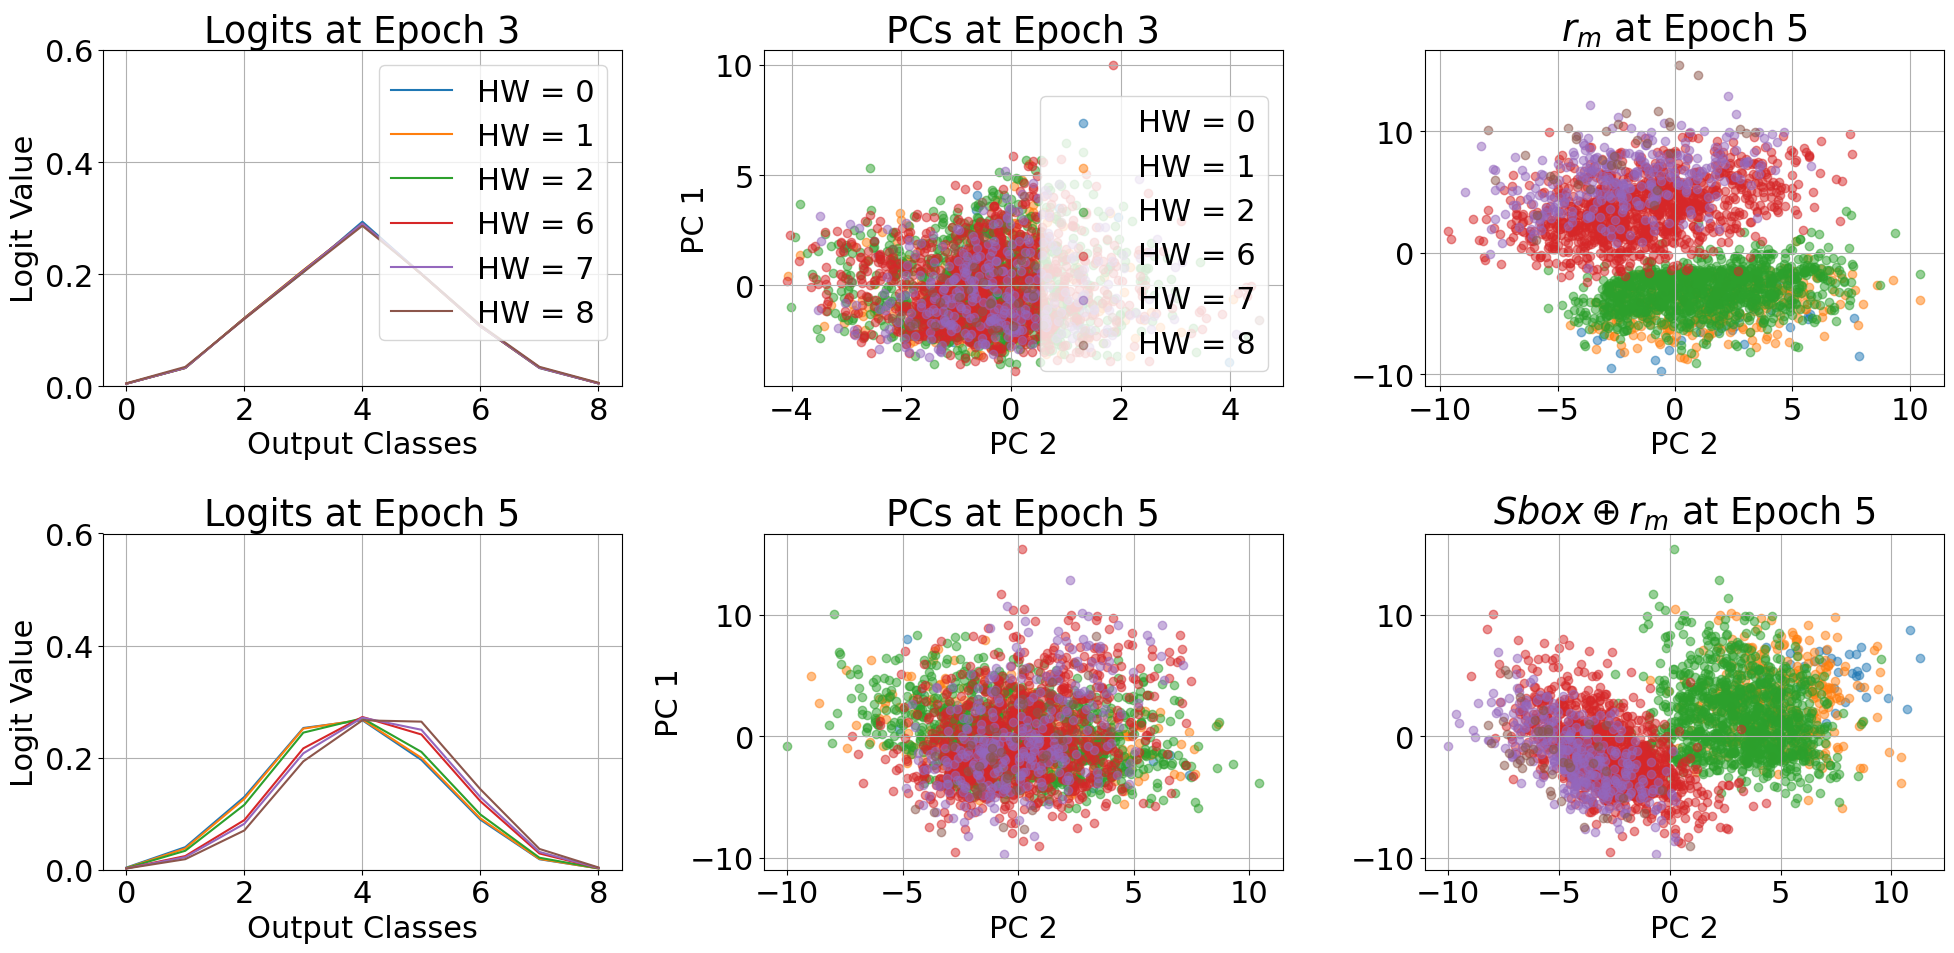

In [15]:
reload_model(3)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^
                dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))
font = {'size'   : 18}
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
#matplotlib.rc('font', **font)
# Prepare logits
out_logits = []
plt.figure(figsize=(20, 10))  # Adjust the figure size for 1x3 layout

# Subplot 1: Logits
plt.subplot(2, 3, 1)
plt.title("Logits at Epoch 3")
for i in [0, 1, 2, 6, 7, 8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
plt.legend()
#plt.title("Logits by HW")
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")

# PCA preparation
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])


in1, in2 = 2, 1

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 2)
plt.title("PCs at Epoch 3")
in1, in2 = 2, 1
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()
plt.legend(loc=4)

# Subplot 3: PC scatter plot for PC1 vs PC0
# plt.subplot(2, 3, 3)
# rm = hw(dataset.share1_attack[target_byte].astype(np.uint8))
# for i in [0, 1, 2, 6, 7, 8]:
#     on, = np.where(rm == i)
#     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
#                 label=f"HW = {i}", alpha=0.5)
# plt.xlabel(f"PC {in1}")
# #plt.ylabel(f"PC {in2}")
# plt.grid()
reload_model(5)
plt.subplot(2, 3, 4)
plt.title("Logits at Epoch 5")
for i in [0, 1, 2, 6, 7, 8]:
    indices, = np.where(dataset.attack_labels == i)
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
plt.ylim([0, 0.6])
plt.grid()
#plt.legend()
#plt.title("Logits by HW")
plt.xlabel("Output Classes")
plt.ylabel("Logit Value")
# PCA preparation
comp_n = 3
new_pca = PCA(n_components=comp_n)
layer = 1
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])

plt.subplot(2, 3, 5)
plt.title("PCs at Epoch 5")
in1, in2 = 2, 1
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(dataset.attack_labels == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.grid()
#plt.legend(loc=4)

# Subplot 3: PC scatter plot for PC1 vs PC0
plt.subplot(2, 3, 3)
plt.title("$r_m$ at Epoch 5")
rm = hw(dataset.share1_attack[target_byte].astype(np.uint8))
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(rm == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()

plt.subplot(2, 3, 6)
plt.title("$Sbox \oplus r_m$ at Epoch 5")
rm = hw(dataset.share2_attack[target_byte].astype(np.uint8))
for i in [0, 1, 2, 6, 7, 8]:
    on, = np.where(rm == i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], 
                label=f"HW = {i}", alpha=0.5)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.grid()
#plt.legend(loc=4)

# Save or show the combined plot
plt.tight_layout()
plt.savefig(f"combined_plots_eshard_lowest.png", dpi=20)
plt.savefig(f"combined_plots_eshard_lower.png", dpi=100)
plt.savefig(f"combined_plots_eshard.png", dpi=200)
plt.show()

  73/2500 [..............................] - ETA: 3s 

2025-01-28 15:30:44.139228: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


313/313 [==============================] - 1s 2ms/step


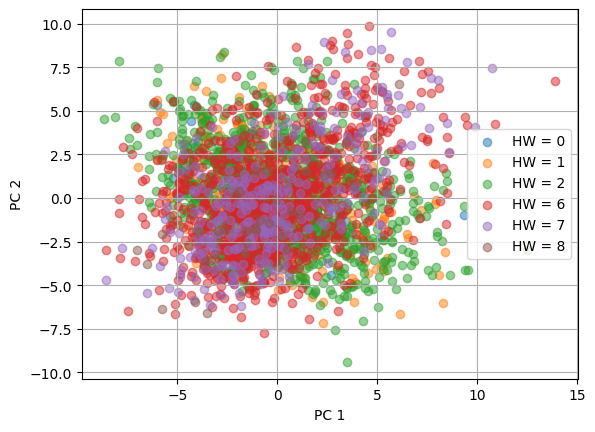

In [6]:
#reload_model(199)
epoch=5
reload_model(epoch)
comp_n= 3
new_pca = PCA(n_components=comp_n)
layer=1
#imp_neurons = np.where(inf_score > np.mean(inf_score))[0]
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
#new_s1_att[:, 0]= 0

theta = np.radians(-25)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])

new_s1_att[:, 1:] = new_s1_att[:, 1:] @rot_matrix

in1 = 1
in2 = 2
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
for i in range(0, 3):
#     if i %2 == 0:
#           continue
     on = np.where(dataset.attack_labels==i)
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
for i in range(6, 9):
#     if i %2 == 0:
#           continue
     on = np.where(dataset.attack_labels==i)
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
     #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.grid()
plt.legend()

#plt.scatter(kmeans.cluster_centers_[:, 2], kmeans.cluster_centers_[:, 1], label="CLSACa")

#plt.scatter(initialize_arr[:, 2], initialize_arr[:, 1], label="CLSACa")#plt.savefig(f"high_low_hw_eshard_epoch_{epoch}.png", dpi=400)
plt.show()
plt.close()
# plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)

# plt.scatter(new_s1_att[fin, in1], new_s1_att[fin, in2],c='g', label="01", alpha=0.1)

# plt.legend()
# plt.title("Even/Odd HW of SBox out for CHES CTF 2018")
# #plt.savefig("pcs_ches.png")
# plt.show()
# plt.close()

313/313 [==============================] - 0s 880us/step


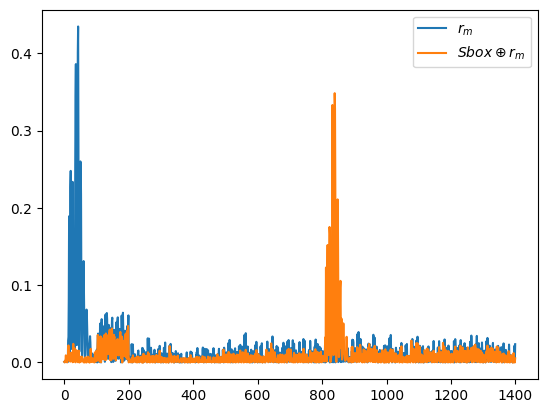

In [7]:
new_model_for_probe = Model(model.layers[layer+1].input, model.output)
copy_for_patch = new_s1_att.copy()
copy_for_patch[:, 2] = -7.5




theta = np.radians(25)  # rotate 180 degrees
rot_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                       [np.sin(theta), np.cos(theta)]])
copy_for_patch[:, 1:] = copy_for_patch[:, 1:] @rot_matrix
predicts_s1 = new_model_for_probe.predict(new_pca.inverse_transform(copy_for_patch))
hw_values_s1 = np.argmax(predicts_s1, axis=1)
prior = np.median(predicts_s1, axis=0)

low_hw_s1 = np.sum(predicts_s1[:, 0:4], axis=1)
high_hw_s1 = np.sum(predicts_s1[:, 5:9], axis=1)
hw_normalized_values_s1 = np.argmax(predicts_s1/prior, axis=1)

plt.plot(snr_fast(dataset.x_attack, hw_values_s1), label="$r_m$")
copy_for_patch = new_s1_att.copy()
copy_for_patch[:, 1] =-7.5

copy_for_patch[:, 1:] = copy_for_patch[:, 1:] @rot_matrix
predicts = new_model_for_probe.predict(new_pca.inverse_transform(copy_for_patch))
hw_values_s2 = np.argmax(predicts, axis=1)

low_hw_s2 = np.sum(predicts[:, 0:4], axis=1)
high_hw_s2 = np.sum(predicts[:, 5:9], axis=1)
prior = np.median(predicts, axis=0)
hw_normalized_values_s2 = np.argmax(predicts/prior, axis=1)
plt.plot(snr_fast(dataset.x_attack, hw_values_s2), label="$Sbox \oplus r_m$")
plt.legend()
plt.show()



In [8]:
print(np.mean(low_hw_s1-high_hw_s1), np.std(low_hw_s1-high_hw_s1))
diff_s1 = high_hw_s1 - low_hw_s1
diff_s2 = high_hw_s2- low_hw_s2

final_hw_values_s1 = np.zeros(len(dataset.x_attack))
final_hw_values_s2 = np.zeros(len(dataset.x_attack))

argsort_s1 = np.argsort(diff_s1).astype(int)
argsort_s2 = np.argsort(diff_s2).astype(int)
hw_prior = np.zeros(9)
for i in range(256):
    hw_prior[hw(i)] += 1
hw_prior/=256
start_index = 0
for i in range(9):
    num_vals = int(len(dataset.x_attack)//(1/hw_prior[i]))
    if i == 4:
        num_vals +=4
    print(num_vals)
    final_hw_values_s1[argsort_s1[start_index:start_index+num_vals]] = i
    final_hw_values_s2[argsort_s2[start_index:start_index+num_vals]] = i
    start_index += num_vals
print(start_index)



0.027000995 0.24133724
39
312
1093
2187
2738
2187
1093
312
39
10000


In [28]:
print(np.sum(new_hw_values_s2 == hw(dataset.share2_attack[target_byte].astype(np.uint8))))
print(np.sum(new_hw_values_s1 == hw(dataset.share1_attack[target_byte].astype(np.uint8))))

from scipy.stats import pearsonr
print(pearsonr(new_hw_values_s1, hw(dataset.share2_attack[target_byte].astype(np.uint8))))

print(pearsonr(new_hw_values_s2, hw(dataset.share1_attack[target_byte].astype(np.uint8))))
# print(np.sum(new_== hw(dataset.share2_attack[target_byte].astype(np.uint8))))
# print(np.sum(hw_normalized_values_s1 == hw(dataset.share1_attack[target_byte].astype(np.uint8))))

# from scipy.stats import pearsonr
# print(pearsonr(hw_normalized_values_s2, hw(dataset.share2_attack[target_byte].astype(np.uint8))))

# print(pearsonr(hw_normalized_values_s1, hw(dataset.share1_attack[target_byte].astype(np.uint8))))

1761
1658
(-0.7630082967850917, 0.0)
(-0.8081331086624444, 0.0)


In [33]:
#copy_for_patch = new_s1_att.copy()

def repeat_product(x, y):
    return np.transpose([np.tile(x, len(y)), 
                            np.repeat(y, len(x))])

from sklearn.cluster import KMeans
kmeans_with_class_erbij = np.append(new_s1_att, ((dataset.attack_labels%2) *1).reshape(-1,1), axis=1)

init_arr_x = np.linspace(-6, 8, 7)
init_arr_y = np.linspace(8, -6, 7)

initialize_arr = repeat_product(init_arr_y, init_arr_x)
label_coords_for_init = np.zeros((len(initialize_arr), 1))
for i in range(len(initialize_arr)):
    label_coords_for_init[i] = ((i+1)%2)*1
initialize_arr_class = np.append(initialize_arr, label_coords_for_init, axis=1)
#print(initialize_arr)
#initialize_arr = np.append(np.zeros((len(initialize_arr), 1)), initialize_arr, axis=1)
initialize_arr_class = np.append(np.zeros((len(initialize_arr), 1)), initialize_arr_class, axis=1)
kmeans = KMeans(len(initialize_arr),init=initialize_arr)

kmeans.fit(new_s1_att[:,1:])
clusters = kmeans.predict(new_s1_att[:, 1:])
kmeans.cluster_centers_

array([[ 6.2118654 , -2.5232642 ],
       [ 4.5702767 , -5.4260087 ],
       [ 2.2210927 , -5.7997794 ],
       [ 0.67366385, -4.4329205 ],
       [-0.84573025, -3.315206  ],
       [-1.8239568 , -4.7018104 ],
       [-3.8235075 , -4.5579877 ],
       [ 8.724864  , -3.4229307 ],
       [ 4.3487444 , -3.4929876 ],
       [ 2.1978474 , -2.9742348 ],
       [ 0.44527084, -2.3172536 ],
       [-1.0861708 , -2.093033  ],
       [-2.7314672 , -2.7848628 ],
       [-6.1728253 , -2.8900352 ],
       [ 5.302245  , -0.07829079],
       [ 3.7719975 , -1.5348892 ],
       [ 2.0109248 , -0.9851557 ],
       [ 0.6479795 , -0.6593612 ],
       [-0.70638484, -0.9660513 ],
       [-2.393442  , -0.9656145 ],
       [-4.125767  , -1.3997681 ],
       [ 8.118084  ,  0.02542148],
       [ 3.3391078 ,  0.86465895],
       [ 1.6461307 ,  0.87315506],
       [-0.0845406 ,  0.8105295 ],
       [-1.4678988 ,  0.213216  ],
       [-2.8906374 ,  0.7993865 ],
       [-4.4447064 ,  0.52577734],
       [ 9.994034  ,

In [32]:
new_hw_values_s1 = (clusters//7) + 1
new_hw_values_s2 = (clusters%7) + 1

0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39
0 39
1 312
2 1093
3 2187
4 2738
5 2187
6 1093
7 312
8 39


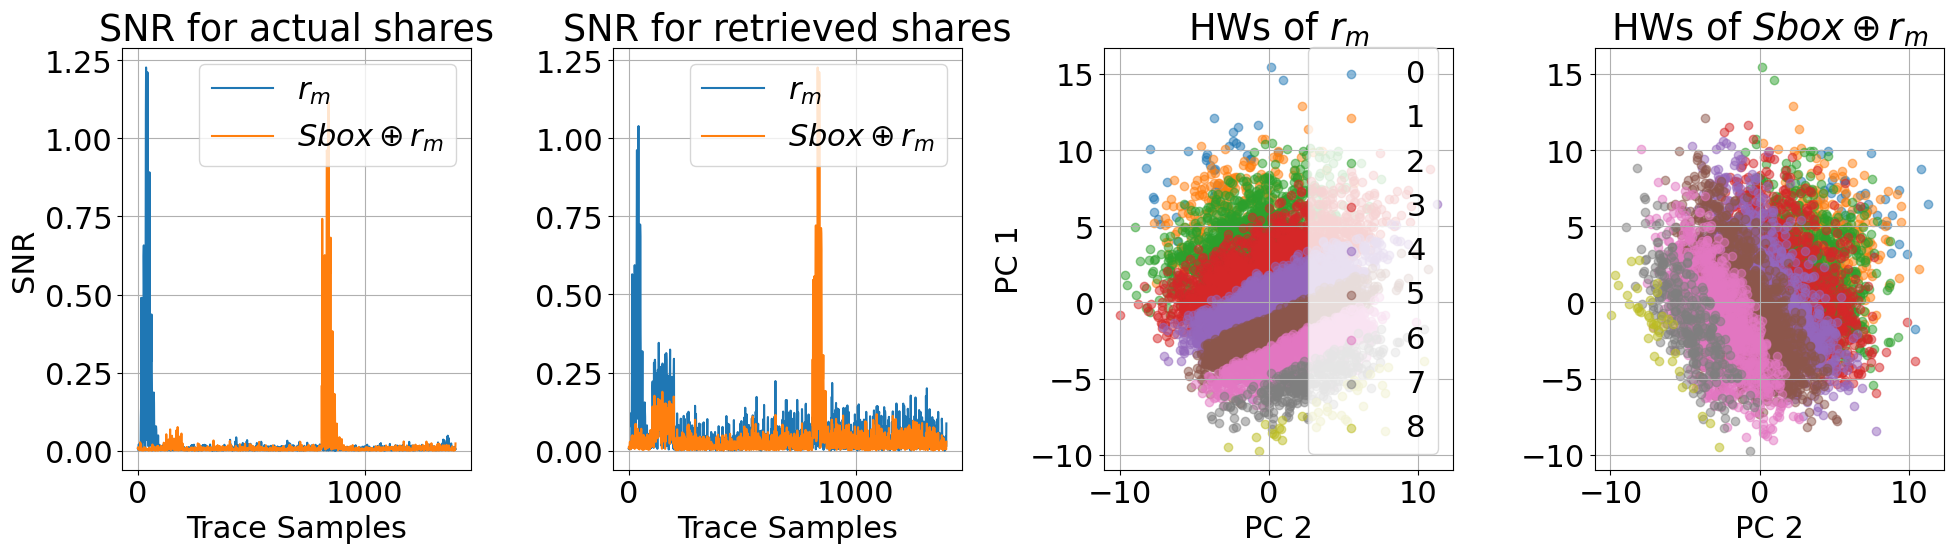

In [12]:
plt.figure(figsize=(20, 6))  # Adjust the figure size for 1x3 layout
comp_n= 3
new_pca = PCA(n_components=comp_n)
layer=1
#imp_neurons = np.where(inf_score > np.mean(inf_score))[0]
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
# Subplot 1: Logits
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
plt.subplot(1, 4, 3)
in1 = 2
in2 = 1
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s1==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"{i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
# for i in range(6, 9):
# #     if i %2 == 0:
# #           continue
#      on = np.where(hw_values_s1==i)
#      plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.title("HWs of $r_m$")
plt.grid()

plt.legend(loc=4)

in1 = 2
in2 = 1
plt.subplot(1,4,4)
plt.xlabel(f"PC {in1}")
#plt.ylabel(f"PC {in2}")
plt.title("HWs of $Sbox \oplus r_m$")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
for i in range(0, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s2==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"{i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
# for i in range(6, 9):
# #     if i %2 == 0:
# #           continue
#      on = np.where(hw_values_s1==i)
#      plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.grid()
#plt.legend()
plt.subplot(1,4,2)
plt.plot(snr_fast(dataset.x_attack, final_hw_values_s1), label="$r_m$")
plt.plot(snr_fast(dataset.x_attack, final_hw_values_s2), label="$Sbox \oplus r_m$") 

plt.title("SNR for retrieved shares")
plt.xlabel("Trace Samples")
plt.legend(loc=1)
plt.grid()
plt.tight_layout()
#plt.ylabel("SNR")


plt.subplot(1,4,1)
plt.plot(snr_fast(dataset.x_attack, hw(dataset.share1_attack[target_byte].astype(np.uint8))), label="$r_m$")
plt.plot(snr_fast(dataset.x_attack, hw(dataset.share2_attack[target_byte].astype(np.uint8))), label="$Sbox \oplus r_m$") 
plt.title("SNR for actual shares")
plt.xlabel("Trace Samples")
plt.ylabel("SNR")
plt.legend(loc=1)
plt.grid()
plt.tight_layout()
plt.savefig("Combined_patch_ehard_lowest_res.png", dpi=20)
plt.savefig("Combined_patch_eshard_lower_res.png", dpi=100)
plt.savefig("Combined_patch_eshard.png", dpi=200)
plt.show()

0 39
1 312
2 1093


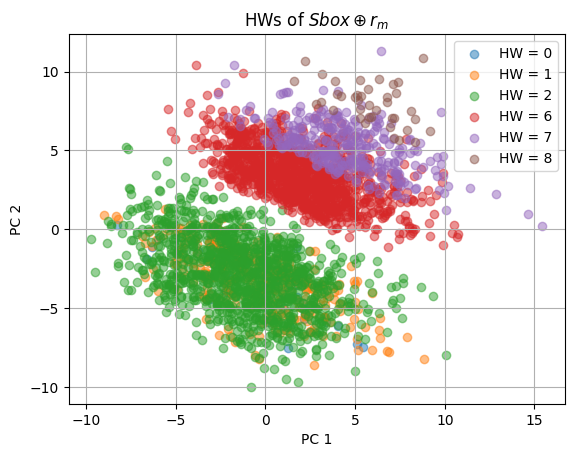

0 39
1 312
2 1093


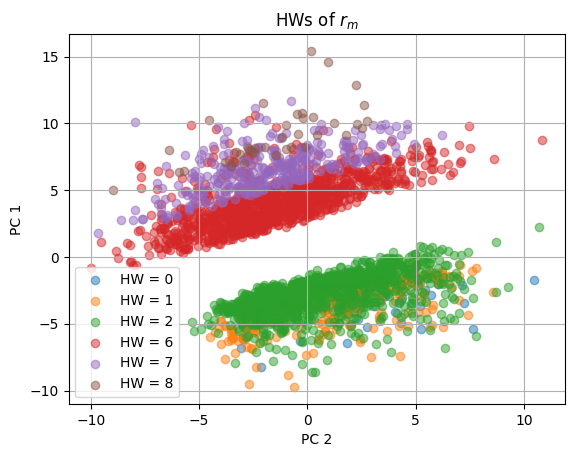

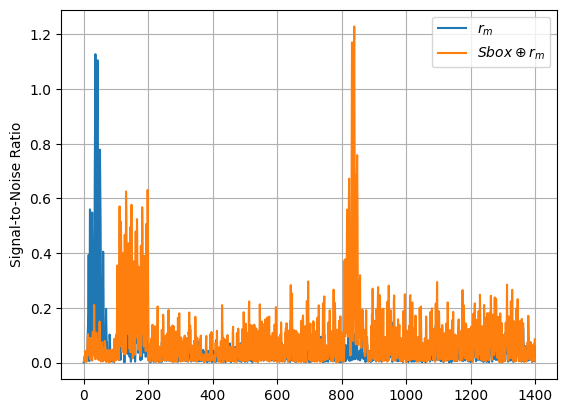

In [10]:
comp_n= 3
new_pca = PCA(n_components=comp_n)
layer=1
#imp_neurons = np.where(inf_score > np.mean(inf_score))[0]
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
in1 = 1
in2 = 2
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.title("HWs of $Sbox \oplus r_m$")
for i in range(0, 3):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s2==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
for i in range(6, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s2==i)
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
     #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)

plt.grid()
plt.legend()


plt.savefig(f"eshard_sbox_patching_epoch_{epoch}.png", dpi=400)
plt.show()
plt.close()

in1 = 2
in2 = 1


plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
plt.title("HWs of $r_m$")
for i in range(0, 3):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s1==i)[0]
     print(i, len(on))
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
for i in range(6, 9):
#     if i %2 == 0:
#           continue
     on = np.where(final_hw_values_s1==i)
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
     #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.grid()
plt.legend()


plt.savefig(f"eshard_rm_patching_{epoch}.png", dpi=400)
plt.show()
plt.close()

plt.plot(snr_fast(dataset.x_attack, final_hw_values_s1), label="$r_m$")

plt.plot(snr_fast(dataset.x_attack, final_hw_values_s2), label="$Sbox \oplus r_m$")
plt.legend()
plt.grid()
plt.ylabel("Signal-to-Noise Ratio")
plt.savefig("eshard_snr.png", dpi=400)
plt.show()

313/313 [==============================] - 0s 1ms/step
[[ 23. 214. 109. ...   3. 148. 251.]
 [ 23. 214. 109. ...   3. 148. 251.]
 [ 23. 214. 109. ...   3. 148. 251.]
 ...
 [ 23. 214. 109. ...   3. 148. 251.]
 [ 23. 214. 109. ...   3. 148. 251.]
 [ 23. 214. 109. ...   3. 148. 251.]]


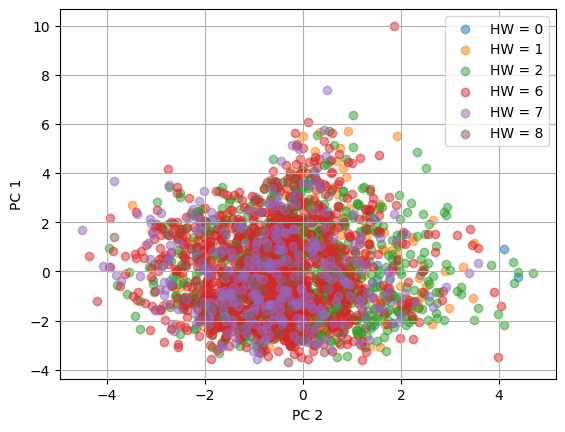

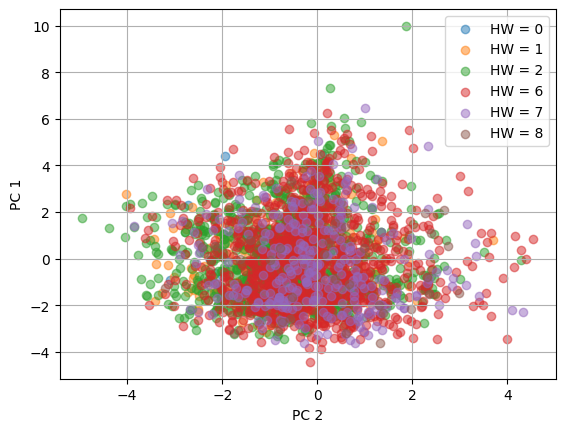

In [34]:
#reload_model(199)
epoch=3
reload_model(epoch)
comp_n= 3
new_pca = PCA(n_components=comp_n)
layer=1
#imp_neurons = np.where(inf_score > np.mean(inf_score))[0]
new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.transform(tmp_att[layer])
#new_s1_att[:, 0]= 0
#print(pi_list[-1], information(new_model_for_probe.predict(new_pca.inverse_transform(new_s1_att)), dataset.attack_labels, 9))
on = np.where(dataset.attack_labels==1)
#on = np.append(on, np.where(dataset.attack_labels==1))
#on = np.append(on, np.where(dataset.attack_labels==2))
off= np.where(dataset.attack_labels==7)
#off = np.append(off, np.where(dataset.attack_labels==7))
#off = np.append(off, np.where(dataset.attack_labels==6))

fin= np.where(dataset.attack_labels==4)

in1 = 2
print(dataset.share1_attack)
in2 = 1
plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
for i in range(0, 3):
#     if i %2 == 0:
#           continue
     on = np.where(hw(dataset.share2_attack[target_byte].astype(np.uint8))==i)
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
for i in range(6, 9):
#     if i %2 == 0:
#           continue
     on = np.where(hw(dataset.share2_attack[target_byte].astype(np.uint8))==i)
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
     #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.grid()
plt.legend()


plt.savefig(f"r_m_sbox_eshard_epoch_{epoch}.png", dpi=400)
plt.show()
plt.close()

plt.xlabel(f"PC {in1}")
plt.ylabel(f"PC {in2}")
for i in range(0, 3):
#     if i %2 == 0:
#           continue
     on = np.where(hw(dataset.share1_attack[target_byte].astype(np.uint8))==i)
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
#      #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
for i in range(6, 9):
#     if i %2 == 0:
#           continue
     on = np.where(hw(dataset.share1_attack[target_byte].astype(np.uint8))==i)
     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=f"HW = {i}", alpha=0.5)
     #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label=i, alpha=0.5)
plt.grid()
plt.legend()


plt.savefig(f"r_m_eshard_epoch_{epoch}.png", dpi=400)
plt.show()
plt.close()
# plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)

# plt.scatter(new_s1_att[fin, in1], new_s1_att[fin, in2],c='g', label="01", alpha=0.1)

# plt.legend()
# plt.title("Even/Odd HW of SBox out for CHES CTF 2018")
# #plt.savefig("pcs_ches.png")
# plt.show()
# plt.close()

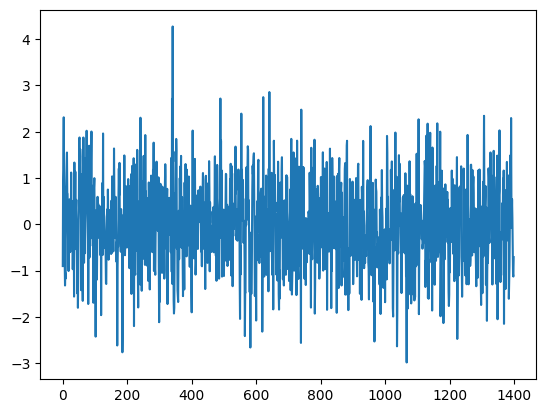

In [7]:
pi_list = []
pi_prof = []
for i in range(1, 101):
    only_reload(i)
    pi = information(model.predict(dataset.x_attack[:5000]), dataset.attack_labels[:5000], 9)
    pi_list.append(pi)

    pi = information(model.predict(dataset.x_profiling[:5000]), dataset.profiling_labels[:5000], 9)
    pi_prof.append(pi)
    print(i, pi, pi_list[-1])


2025-01-26 10:07:34.362038: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


157/157 [==============================] - 0s 1ms/step


1 0.0031016680914295984 -0.019393597611347693
157/157 [==============================] - 0s 1ms/step


2 0.008787263794554651 -0.014959517105976601
157/157 [==============================] - 0s 1ms/step


3 0.007689400025023017 -0.0153275819863474
157/157 [==============================] - 0s 1ms/step


...

157/157 [==============================] - 0s 1ms/step
96 0.23231022064269904 -0.21416489888087872


157/157 [==============================] - 0s 1ms/step
97 0.23197643158019868 -0.16761732808009785


157/157 [==============================] - 0s 1ms/step


98 0.21794565155090187 -0.19815641194240213
157/157 [==============================] - 0s 1ms/step


99 0.22116191589416337 -0.16793960286037088
157/157 [==============================] - 0s 1ms/step
100 0.23654773132385076 -0.17688676777736323


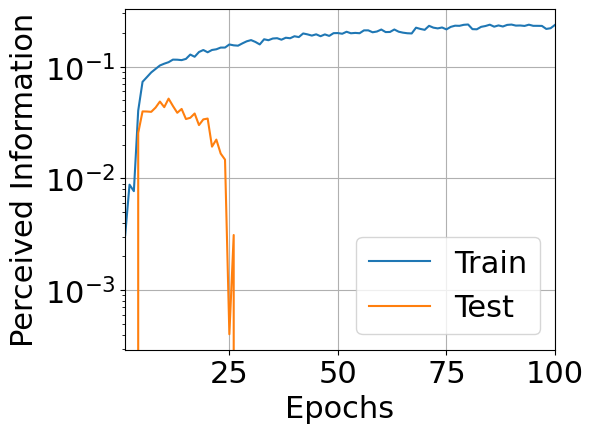

In [8]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 22
plt.plot(range(1, 101), pi_prof, label="Train")
plt.plot(range(1, 101), pi_list, label="Test")

plt.yscale('log')
plt.xlabel("Epochs")
plt.ylabel("Perceived Information")
plt.grid()
plt.legend()
plt.xlim([1, 100])
plt.tight_layout()
plt.savefig("PI_eshard.png", dpi=200)
plt.show()

313/313 [==============================] - 0s 1ms/step


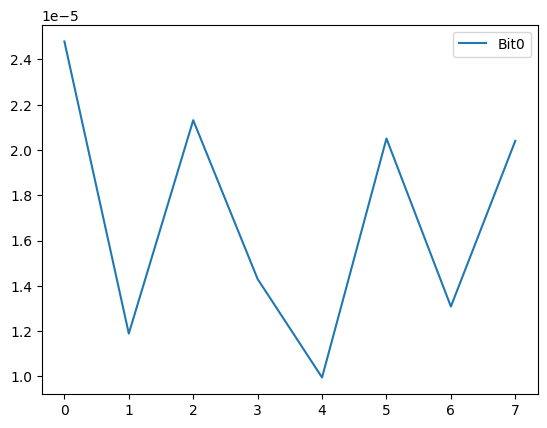

In [67]:
reload_model(100)
layer=1
new_model_for_probe = Model(model.layers[layer+1].input, model.output)
comp_n = 8
new_pca = PCA(n_components=comp_n)
#new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
in_neurons = tf.Variable(new_s1_att)

inf_scores = np.zeros((16, comp_n))
for i in [0]:
    with tf.GradientTape() as tape:
        inter = new_pca.inverse_transform(in_neurons)
        predicts = new_model_for_probe(inter, training=False)
        
        #[:, 1] #+ probes_for_bit[i+1](inter, training=False)[:, 0]
        loss = tf.keras.losses.CategoricalCrossentropy()( predicts, dataset.y_attack)
                
        # predicts =  probes_for_bit[i](inter, training=True)#[:, 1] #+ probes_for_bit[i+1](inter, training=False)[:, 0]
        # loss = tf.keras.losses.CategoricalCrossentropy()( predicts, tf.keras.utils.to_categorical((dataset.attack_labels>>i)&0x1))

    grads = tape.gradient(loss, in_neurons)
    dgrad_abs = tf.math.abs(grads)

    inf_score = np.average(dgrad_abs.numpy(), axis=0)
    #inf_scores[i] = inf_score
    #print(inf_score)
    
    plt.plot(inf_score, label=f"Bit{i}")
# plt.plot(bit_on_sum)
# plt.plot(bit_off_sum)
plt.legend()
plt.show()

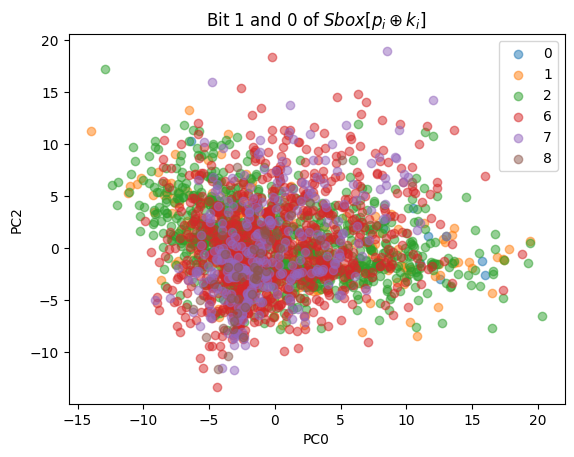

In [72]:
reload_model()
comp_n= 4
new_pca = PCA(n_components=comp_n)
layer=1
#new_s1_prof = new_pca.fit_transform(tmp[layer])
new_s1_att = new_pca.fit_transform(tmp_att[layer])
#new_s1_att = tmp_att[layer]
on = np.where(dataset.attack_labels==1)
#on = np.append(on, np.where(dataset.attack_labels==1))
#on = np.append(on, np.where(dataset.attack_labels==2))
off= np.where(dataset.attack_labels==7)
#off = np.append(off, np.where(dataset.attack_labels==7))
#off = np.append(off, np.where(dataset.attack_labels==6))

fin= np.where(dataset.attack_labels==4)

in1 = 0
in2 = 2
plt.xlabel(f"PC{in1}")
plt.ylabel(f"PC{in2}")
#plt.scatter(new_s1_att[:, in1], new_s1_att[:, in2], label="all", alpha=0.1)
# for i in range(0, 2):
#     on = np.where(dataset.attack_labels %2 == i)
#     plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label="Even HW" if i == 0 else "Odd HW", alpha=0.5)
#     #plt.scatter(tmp_att[layer][on, in1], tmp_att[layer][on, in2], label="Even HW" if i == 0 else "Odd HW", alpha=0.5)

for i in range(0,3):
    on = np.where(dataset.attack_labels==i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=i, alpha=0.5)

for i in range(6, 9):
    on = np.where(dataset.attack_labels==i)
    plt.scatter(new_s1_att[on, in1], new_s1_att[on, in2], label=i, alpha=0.5)

# plt.scatter(new_s1_att[off, in1], new_s1_att[off, in2],c='#ff7f0e', label="01", alpha=0.5)

# plt.scatter(new_s1_att[fin, in1], new_s1_att[fin, in2],c='g', label="01", alpha=0.1)

plt.legend()
plt.title("Bit 1 and 0 of $Sbox[p_i \oplus k_i]$")
plt.show()
plt.close()

313/313 [==============================] - 0s 1ms/step
298
10/10 [==============================] - 0s 1ms/step
2699
85/85 [==============================] - 0s 979us/step
320
10/10 [==============================] - 0s 1ms/step
[array([0.00668414, 0.04153433, 0.14086543, 0.22794965, 0.26294455,
       0.19768552, 0.09470385, 0.02434705, 0.00328549], dtype=float32), array([0.00412899, 0.03145988, 0.11444033, 0.21439178, 0.26683226,
       0.21334094, 0.11877647, 0.03229431, 0.00433434], dtype=float32), array([0.00229248, 0.02194051, 0.09100498, 0.19026038, 0.2604739 ,
       0.23188582, 0.14971203, 0.04618387, 0.00624584], dtype=float32)]


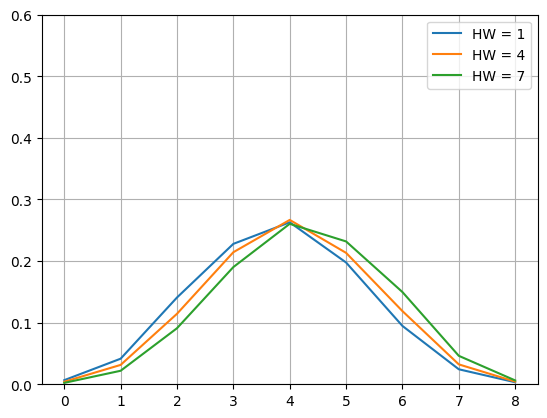

In [33]:
out_logits = []
epoch=99
reload_model(epoch)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

for i in [1, 4, 7]:
    indices, =np.where((dataset.attack_labels == i))
    #indices_other, = np.where(sbox_ins_att  % 4 == (i >>2) %4)
    #final_indices = np.intersect1d(indices, indices_other)
    print(len(indices))
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
    plt.ylim([0, 0.6])
    #

    #plt.savefig(f"logits_{i}_epoch_{epoch}.png", dpi=400)
    #plt.show()
plt.grid()
plt.legend()
plt.savefig(f"logits_eshard_epoch_{epoch}.png", dpi=400)
print(out_logits)



313/313 [==============================] - 0s 1ms/step
2514
79/79 [==============================] - 0s 994us/step
21704
679/679 [==============================] - 1s 990us/step
2611
82/82 [==============================] - 0s 1ms/step
[array([0.01188825, 0.06721265, 0.17309894, 0.23713647, 0.23732843,
       0.16125943, 0.08076917, 0.02740248, 0.00390486], dtype=float32), array([0.00296795, 0.02643593, 0.10613824, 0.21472415, 0.2835326 ,
       0.22226234, 0.11469091, 0.02597623, 0.0032716 ], dtype=float32), array([0.00480513, 0.02585603, 0.07135068, 0.1519974 , 0.20860797,
       0.22211322, 0.18759158, 0.10959723, 0.01808047], dtype=float32)]


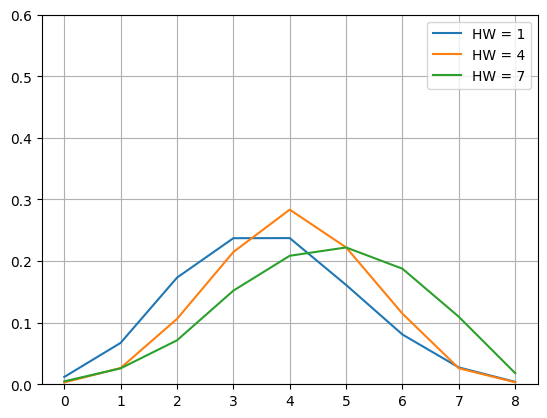

In [32]:
out_logits = []
epoch=99
reload_model(epoch)
sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

for i in [1, 4, 7]:
    indices, =np.where((dataset.profiling_labels == i))
    #indices_other, = np.where(sbox_ins_att  % 4 == (i >>2) %4)
    #final_indices = np.intersect1d(indices, indices_other)
    print(len(indices))
    logits = model.predict(dataset.x_profiling[indices])
    out_logits.append(np.mean(logits, axis=0))
    plt.plot(out_logits[-1], label=f"HW = {i}")
    plt.ylim([0, 0.6])
    #

    #plt.savefig(f"logits_{i}_epoch_{epoch}.png", dpi=400)
    #plt.show()
plt.grid()
plt.legend()
plt.savefig(f"logits_eshard_prof_epoch_{epoch}.png", dpi=400)
print(out_logits)

In [ ]:
fix_in_01 = new_s1_att.copy()
fix_in_01[:, 1] = 16
fix_in_01[:, 2] = 12
fix_in_10 = new_s1_att.copy()
fix_in_10[:, 1] = 15
fix_in_10[:, 2] = -10
outs = []
new_model_for_probe = Model(model.layers[layer+1].input, model.layers[layer_out].output)
patched_activs = new_model_for_probe.predict(new_pca.inverse_transform(fix_in_01))
for i in range(8):
    outs.append(probes_for_bit[i].predict(patched_activs))
outs2 = []
patched_activs = new_model_for_probe.predict(new_pca.inverse_transform(fix_in_10))
for i in range(8):
    outs2.append(probes_for_bit[i].predict(patched_activs))



# for i in range(16):
#     print(f"in = {bin(i%4)}, out = {bin(i//4)}", matrix[i, :])       


In [ ]:

matrix = np.zeros((16, 8))
matrix_in = np.zeros((16, 8))
for i in range(256):
    for bit in range(8):
        matrix[(i) %4 + (aes_sbox[i]%4)*4, bit] += (aes_sbox[i]>>bit) &0x1
        matrix_in[((i) %4)*4 + (aes_sbox[i]%4), bit] += (i>>bit) &0x1

print(matrix)
print(matrix_in)
out_bit = 0
indices_00, = np.where((dataset.attack_labels) % 2 == out_bit)
for pred_bit in range(2,8):
#pred_bit = 4

    print(1, pred_bit, matrix[1, pred_bit], np.sum((np.argmax(outs[pred_bit],axis=1))))
    print(2, pred_bit, matrix[0, pred_bit], np.sum((np.argmax(outs2[pred_bit],axis=1))))


In [12]:
reload_model(5)
print(information(model.predict(dataset.x_attack), dataset.attack_labels, 9))

313/313 [==============================] - 0s 991us/step
0.03044261958346786


44
2/2 [==============================] - 0s 2ms/step


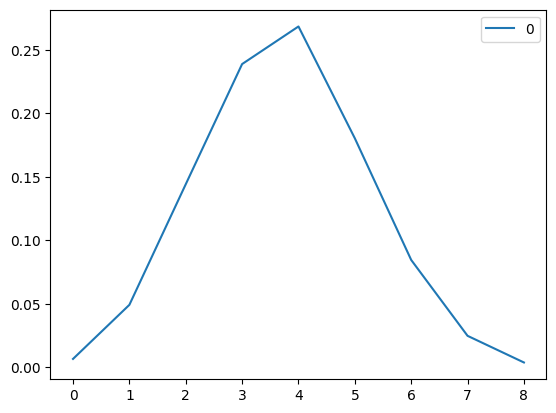

298
10/10 [==============================] - 0s 2ms/step


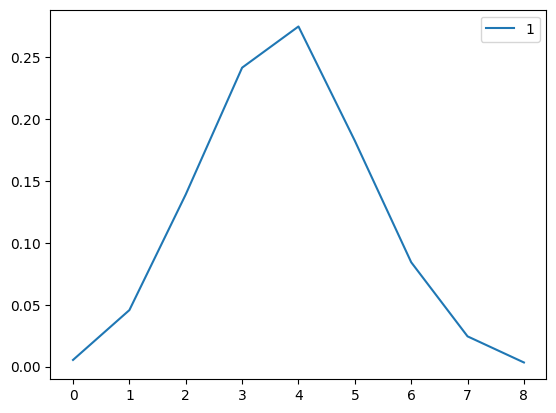

1085
34/34 [==============================] - 0s 2ms/step


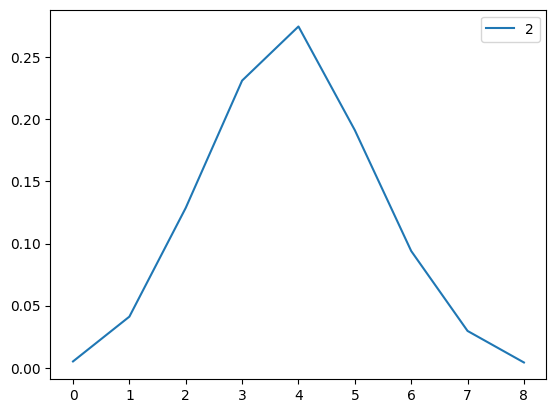

2290
72/72 [==============================] - 0s 2ms/step


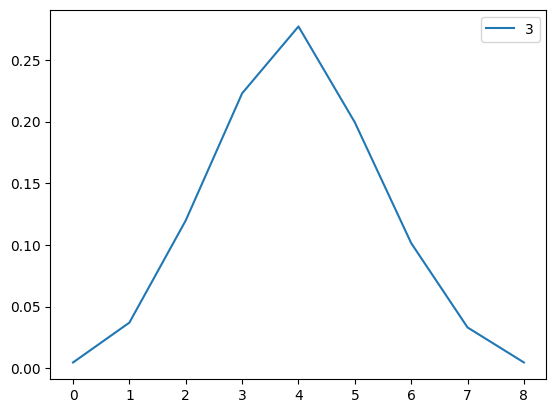

2699
85/85 [==============================] - 0s 2ms/step


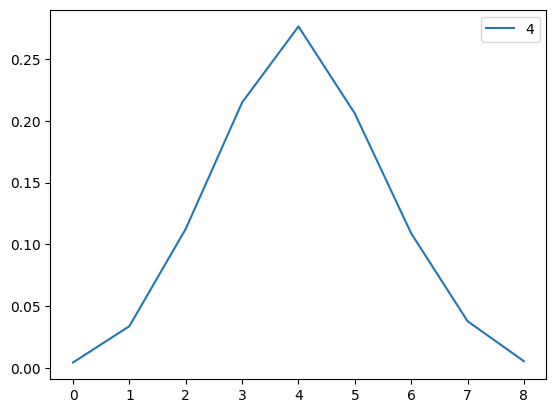

2143
67/67 [==============================] - 0s 1ms/step


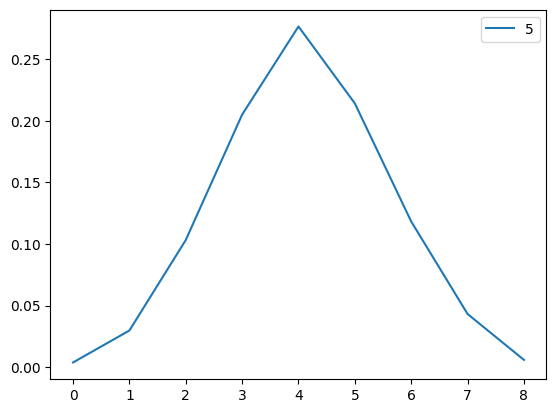

1079
34/34 [==============================] - 0s 1ms/step


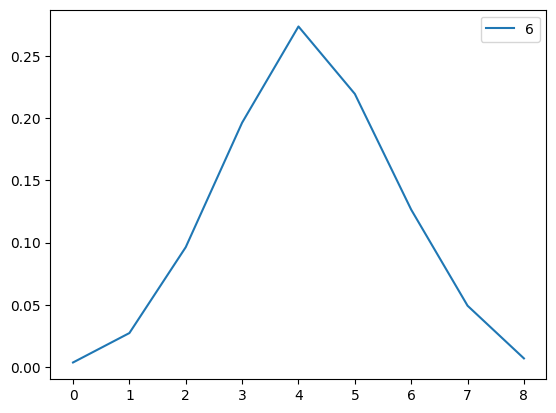

320
10/10 [==============================] - 0s 1ms/step


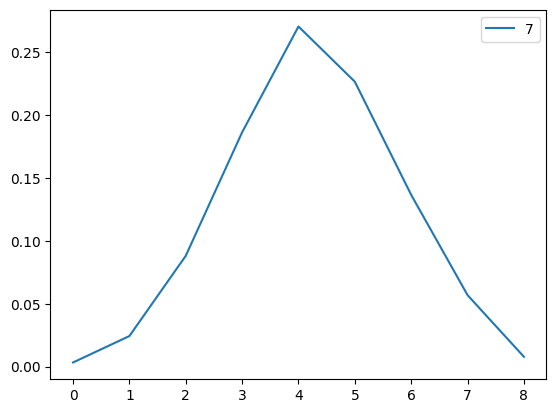

42
2/2 [==============================] - 0s 3ms/step


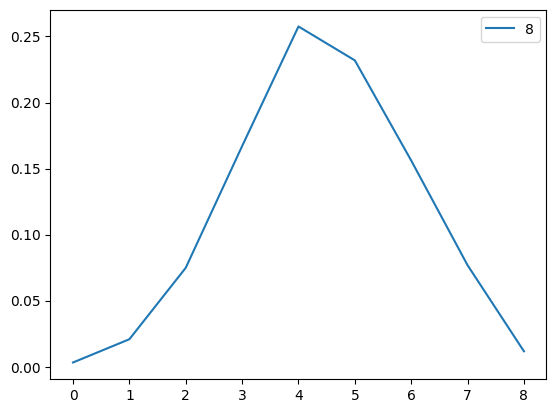

[array([0.00649213, 0.04909688, 0.14409932, 0.23877946, 0.26839423,
       0.1803003 , 0.08446049, 0.0246862 , 0.00369101], dtype=float32), array([0.00542618, 0.04563431, 0.1389552 , 0.24122152, 0.27445984,
       0.1822402 , 0.08423877, 0.02444463, 0.00337942], dtype=float32), array([0.00504741, 0.04111584, 0.12872294, 0.23123568, 0.2748146 ,
       0.19129132, 0.09397917, 0.02959624, 0.00419692], dtype=float32), array([0.00458313, 0.03692376, 0.11984143, 0.22296081, 0.27723715,
       0.19942297, 0.10143254, 0.03299955, 0.00459855], dtype=float32), array([0.00430996, 0.03371313, 0.11255433, 0.21492821, 0.27651438,
       0.20598063, 0.10892254, 0.03774496, 0.00533227], dtype=float32), array([0.00379547, 0.02974019, 0.10319389, 0.2050201 , 0.27664566,
       0.21420637, 0.11829939, 0.04317733, 0.0059216 ], dtype=float32), array([0.00360852, 0.0272717 , 0.09636543, 0.19649686, 0.27388954,
       0.21966247, 0.12654456, 0.04926986, 0.0068909 ], dtype=float32), array([0.00327028, 0.02428

In [66]:
out_logits = []

sbox_ins_att = (dataset.attack_plaintexts[:, dataset.target_byte].astype(np.uint8) ^ dataset.attack_keys[:, dataset.target_byte].astype(np.uint8))

for i in range(9):
    indices, =np.where((dataset.attack_labels == i))
    #indices_other, = np.where(sbox_ins_att  % 4 == (i >>2) %4)
    #final_indices = np.intersect1d(indices, indices_other)
    print(len(indices))
    logits = model.predict(dataset.x_attack[indices])
    out_logits.append(np.average(logits, axis=0))
    plt.plot(out_logits[i], label=i)

    plt.legend()
    plt.show()
print(out_logits)


In [ ]:

for i in range(16):
     ins, = np.where(out_logits[i] > 0.005)
     print(i, ins)
     in_sboxes = []
     out_sboxes = []
     for j in range(256):
          if (j) % 4 == (i>>2):
               in_sboxes.append(aes_sbox[j])
          if j % 4 == i %4:
               out_sboxes.append(j)
     
     print(i, np.sort(np.intersect1d(in_sboxes, out_sboxes)))
#np.argsort(out_logits[1])[::-1]
#np.argsort(out_logits[2])[::-1]
